In [2]:
!gdown 1mc89F1dkQ6XRQnwQTqqryjaXt5ZWXTT0
!unzip BTC-Daily.zip

Downloading...
From: https://drive.google.com/uc?id=1mc89F1dkQ6XRQnwQTqqryjaXt5ZWXTT0
To: /content/BTC-Daily.zip
100% 95.7k/95.7k [00:00<00:00, 88.5MB/s]
unzip:  cannot find or open BTC-daily.zip, BTC-daily.zip.zip or BTC-daily.zip.ZIP.


In [76]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt


In [35]:
df = pd.read_csv('/content/BTC-Daily.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2651 entries, 0 to 2650
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unix        2651 non-null   int64  
 1   date        2651 non-null   object 
 2   symbol      2651 non-null   object 
 3   open        2651 non-null   float64
 4   high        2651 non-null   float64
 5   low         2651 non-null   float64
 6   close       2651 non-null   float64
 7   Volume BTC  2651 non-null   float64
 8   Volume USD  2651 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 186.5+ KB


In [45]:
df.drop_duplicates()
df.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD,year,month,day
0,1646092800,2022-03-01,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06,2022,3,1
1,1646006400,2022-02-28,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08,2022,2,28
2,1645920000,2022-02-27,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07,2022,2,27
3,1645833600,2022-02-26,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07,2022,2,26
4,1645747200,2022-02-25,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07,2022,2,25


In [54]:
# @title EDA
#Show shape
print(f"Data shape: {df.shape}")

#Convert to datetime
df['date'] = pd.to_datetime(df['date'], errors="coerce")

data_range = str(df['date'].dt.date.min()) + " To " + str(df['date'].dt.date.max())
print(data_range)

#Create time features

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day




Data shape: (2651, 12)
2014-11-28 To 2022-03-01


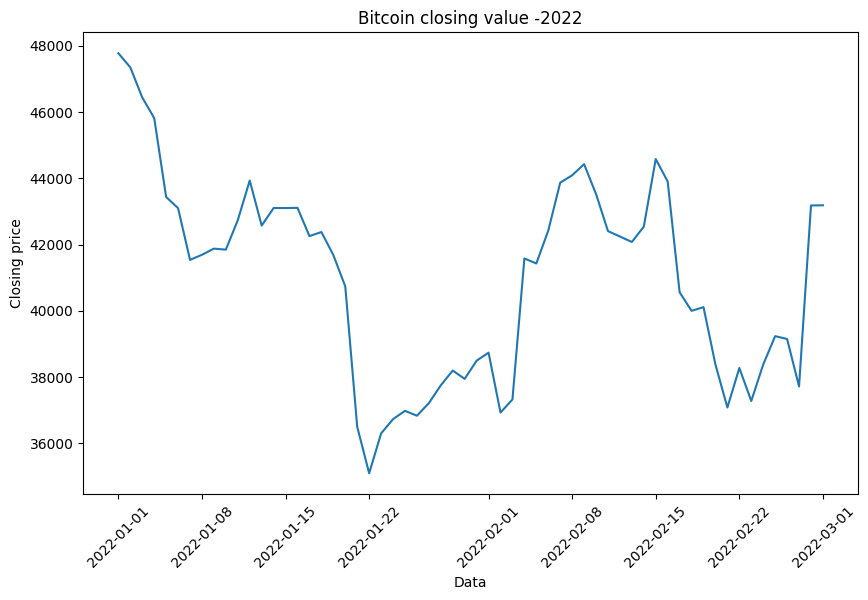

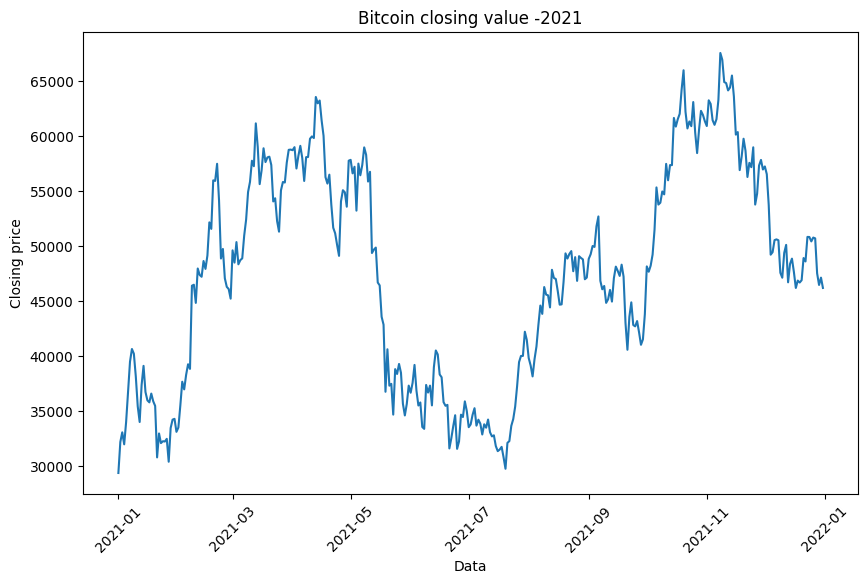

In [84]:
unique_year = df['year'].unique()

for year in unique_year[:2]:
  dates = pd.date_range(start = f"{year}-01-01", end = f"{year}-12-31", freq = "D")

  year_month_day = pd.DataFrame({"date" : dates})
  year_month_day['year'] = year_month_day['date'].dt.year
  year_month_day['month'] = year_month_day['date'].dt.month
  year_month_day['day'] = year_month_day['date'].dt.day

  merged_data = pd.merge(year_month_day, df, on = ["year", "month", "day"], how = "left")

  #
  plt.figure(figsize=(10,6))
  plt.plot(merged_data["date_x"], merged_data["close"])
  plt.title(f"Bitcoin closing value -{year}")
  plt.xlabel("Data")
  plt.ylabel("Closing price")
  plt.xticks(rotation=45)
  plt.tight_layout
  plt.show()



In [ ]:
%pip install mplfinance


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.7 MB/s eta 0:00:00


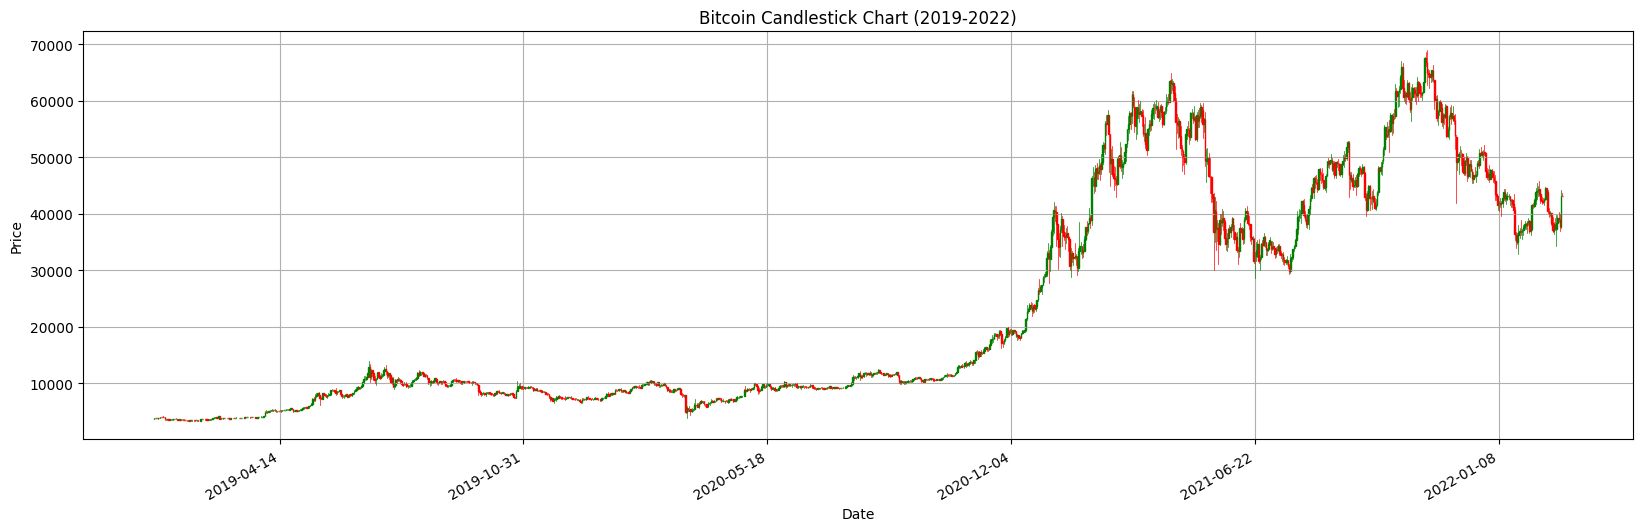

In [91]:
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
import datetime

df_filtered = df[(df["date"] >= "2019-01-01")  & (df["date"] <= "2022-12-31")].copy()

df_filtered["date"] = df_filtered["date"].map(mdates.date2num)

fig, ax = plt.subplots(figsize=(20,6))

candlestick_ohlc(ax, df_filtered[["date", "open", "high", "low", "close"]].values,
width=0.6, colorup="g", colordown="r")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()

plt.title("Bitcoin Candlestick Chart (2019-2022)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

plt.savefig("bitcoin_candlestick_2019_2022.pdf")
plt.show()









In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df[["open", "low", "high"]].values
y = df["close"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state= 42, shuffle=True )

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [338]:
def predict(X, w, b):
  y_preds = np.dot(X, w) + b
  return y_preds

def gradient(y_hat, y, x):
  n_samples, n_features = X.shape
  dw = (np.dot(x.T, y_hat - y)) / n_samples
  db = (y_hat - y).sum() / n_samples
  cost = (1/2 * (y_hat - y).dot((y_hat - y).T)).sum()
  return (dw, db, cost)

def update_weight(w,b,lr,dw,db):
  w_new = w - lr*dw
  b_new = b - lr*db
  return (w_new, b_new)


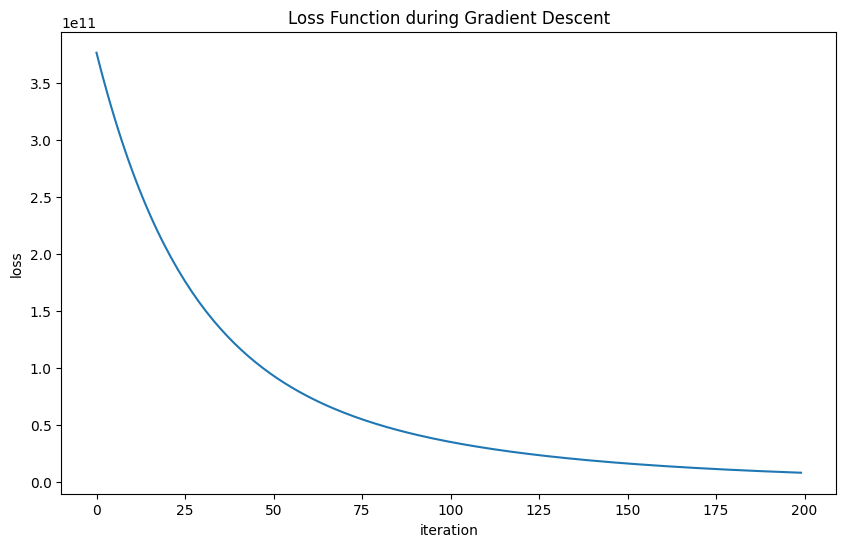

In [343]:
def linear_regresstion_vectorized (X, y, lr= 0.1, num_iterations = 200):
  n_samples, n_features = X.shape
  w = np.zeros(n_features) # Initialize weights
  b = 0 # Initialize bias
  losses = []


  for iteration in range(200):
    y_hat = predict(X, w, b)


    dw, db, cost = gradient (y_hat, y, X)

    w, b = update_weight(w,b,lr = lr, dw = dw, db= db)

    losses.append(cost)

  return w, b, losses

w, b, losses = linear_regresstion_vectorized(X_train_scaled, y_train, lr = 0.01)

plt.figure(figsize =(10,6))
plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Loss Function during Gradient Descent")
plt.show()







In [348]:
from sklearn.metrics import r2_score

y_pred = predict(X_test_scaled, w , b)


# Calculate RMSE
rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))

# Calculate MAE
mae = np.mean(np.abs(y_pred - y_test))

# Calculate MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100


# Calculate R-squared on training data
y_train_pred = predict(X_train_scaled, w, b)
train_accuracy = r2_score(y_train, y_train_pred)

# Calculate R-squared on testing data
test_accuracy = r2_score(y_test, y_pred)


print("Root Mean Square Error (RMSE):", round(rmse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("Training Accuracy (R-squared):", round(train_accuracy, 4))
print("Testing Accuracy (R-squared):", round(test_accuracy, 4))





Root Mean Square Error (RMSE): 2927.6023
Mean Absolute Error (MAE): 2876.9283
Training Accuracy (R-squared): 0.968
Testing Accuracy (R-squared): 0.9665
